# LendingClub PD – Data Wrangling, Outlier Study & Feature Engineering

**Purpose:** Single source of truth for PD (Probability of Default) inputs:
1. Load and wrangle LoanStats3a-style data (target definition, missing values, types).
2. Run an **outlier study** (distributions, caps/winsorization) to avoid leakage and stabilize models.
3. Build **15 high-impact features** via `credit_risk.feature_engineering.common_features` (shared by XGBoost and quantum PD models).
4. Save a cleaned, feature-level dataset for downstream training notebooks.

**Data:** Place `LoanStats3a.csv` (or equivalent) under `data/credit_risk_pd/LendingClub/`. On **Kaggle**, add the CSV as an input dataset; the notebook auto-detects Kaggle and searches `/kaggle/input` for a CSV. Columns expected: `loan_amnt`, `int_rate`, `installment`, `grade`, `emp_length`, `annual_inc`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `loan_status`; FICO from `fico_range_low` / `fico_range_high` if present.

## 1. Setup and load raw data

In [11]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Detect Kaggle (auto); or set IN_KAGGLE = True below if detection fails
IN_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/working").exists()
if IN_KAGGLE:
    # Kaggle: repo may be at /kaggle/working/ocr-agentic-rag (after clone) or /kaggle/working
    _kaggle_repo = Path("/kaggle/working/ocr-agentic-rag")
    ROOT = _kaggle_repo if (_kaggle_repo / "credit_risk").exists() else Path("/kaggle/working")
    if not (ROOT / "credit_risk").exists():
        get_ipython().system("git clone --depth 1 https://github.com/leemingloon/ocr-agentic-rag.git")
        get_ipython().run_line_magic("cd", "ocr-agentic-rag")
        ROOT = Path(".").resolve()
else:
    ROOT = Path(".").resolve() if (Path(".").resolve() / "credit_risk").exists() else Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "credit_risk_pd" / "LendingClub"
OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LoanStats3a CSV: repo data dir, or on Kaggle search /kaggle/input for any CSV
csv_path = DATA_DIR / "LoanStats3a.csv"
if not csv_path.exists():
    csvs = list(DATA_DIR.glob("*.csv"))
    csv_path = csvs[0] if csvs else None
if (csv_path is None or not csv_path.exists()) and IN_KAGGLE:
    csv_path = None
    for d in sorted(Path("/kaggle/input").iterdir()):
        csvs = list(d.glob("*.csv"))
        if csvs:
            csv_path = max(csvs, key=lambda p: p.stat().st_size)
            break
if csv_path is None or not csv_path.exists():
    raise FileNotFoundError("Place LoanStats3a.csv under data/credit_risk_pd/LendingClub/ or add as Kaggle input dataset.")

df_raw = pd.read_csv(csv_path, skiprows=1, low_memory=False)
# Remove footer row if present ("Total amount funded" etc.)
df_raw = df_raw[~df_raw.iloc[:, 0].astype(str).str.contains("Total", na=False)]
# Best practice: drop non-predictive columns (IDs, URL, free text)
drop_cols = [c for c in ["id", "member_id", "url", "desc"] if c in df_raw.columns]
if drop_cols:
    df_raw = df_raw.drop(columns=drop_cols)
    print(f"Dropped non-predictive columns: {drop_cols}")
print(f"Loaded {len(df_raw):,} rows. Columns: {list(df_raw.columns[:20])}...")

Dropped non-predictive columns: ['id', 'member_id', 'url', 'desc']
Loaded 42,536 rows. Columns: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state']...


In [12]:
# Drop columns with >30% missing except fields required by the downstream feature pipeline.
REQUIRED_FOR_PIPELINE = {
    "loan_status", "issue_d", "term", "loan_amnt", "installment", "annual_inc", "dti",
    "delinq_2yrs", "revol_util", "revol_bal", "open_acc", "total_acc", "inq_last_6mths",
    "emp_length", "fico_range_low", "fico_range_high", "home_ownership", "verification_status",
    "purpose", "grade", "sub_grade", "int_rate", "addr_state", "application_type",
    "initial_list_status", "earliest_cr_line", "emp_title",
}
missing_pct = df_raw.isnull().mean() * 100
drop_high_missing = [c for c in df_raw.columns if c not in REQUIRED_FOR_PIPELINE and missing_pct[c] > 30]
if drop_high_missing:
    df_raw = df_raw.drop(columns=drop_high_missing)
    print(f"Dropped {len(drop_high_missing)} columns with >30% missing: {drop_high_missing[:15]}{'...' if len(drop_high_missing) > 15 else ''}")
print(f"Columns remaining: {len(df_raw.columns)}")

Dropped 88 columns with >30% missing: ['mths_since_last_delinq', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il']...
Columns remaining: 52


**Data preparation and feature engineering:** Columns with >30% missing are dropped (keeping pipeline-required fields); ID/URL/description columns are dropped; missing rates are reported; `annual_inc`, `revol_util`, and `dti` are winsorized; `open_acc` is capped at 30; the time-based OOT split by `issue_d` is applied before any scaling; the no-leakage feature set and log transforms live in `common_features`.

## 2. Target definition (binary default)

LendingClub `loan_status` includes: Current, Fully Paid, Charged Off, Late, In Grace Period, etc. This notebook defines **default = 1** for Charged Off (and optionally severe delinquency); **non-default = 0** for Fully Paid (and optionally Current). To limit censoring in the binary label, only **Fully Paid** vs **Charged Off** are retained.

In [13]:
col_status = "loan_status"
if col_status not in df_raw.columns:
    col_status = [c for c in df_raw.columns if "status" in c.lower()][0] if any("status" in c.lower() for c in df_raw.columns) else None
if col_status is None:
    raise ValueError("No loan_status column found")

df_raw["loan_status"] = df_raw[col_status].astype(str).str.strip()
# Binary default label: default = Charged Off, Default, Late (31-120); non-default = Fully Paid only; drop ambiguous statuses.
default_statuses = {"Charged Off", "Default", "charged off", "default", "Late (31-120 days)", "late (31-120 days)"}
paid_statuses = {"Fully Paid", "fully paid"}

mask_default = df_raw["loan_status"].isin(default_statuses)
mask_paid = df_raw["loan_status"].isin(paid_statuses)
df = df_raw[mask_default | mask_paid].copy()
df["default"] = mask_default[mask_default | mask_paid].astype(int)
print(df["default"].value_counts())
print(f"Retained {len(df):,} rows with binary target (default vs fully paid only; ambiguous dropped).")

# Default definition sensitivity: broad (includes Late 31-120) vs strict (Charged Off / Default only)
_strict_default = df["loan_status"].isin({"Charged Off", "Default", "charged off", "default"})
_broad_default = df["default"] == 1
_n = len(df)
print("Default definition sensitivity:")
print(f"  Broad  (Charged Off + Default + Late 31-120): "
      f"{_broad_default.sum():,} / {_n:,} = {_broad_default.mean():.3%}")
print(f"  Strict (Charged Off + Default only):          "
      f"{_strict_default.sum():,} / {_n:,} = {_strict_default.mean():.3%}")
print(f"  Late 31-120 loans added to default pool: {(_broad_default & ~_strict_default).sum():,}")
_n_late_added = (_broad_default & ~_strict_default).sum()
if _n_late_added == 0:
    print()
    print("NOTE: In this extract, Late 31-120 count = 0. Broad and strict definitions")
    print("are numerically identical. The 'broad' label is retained for documentation")
    print("consistency; re-validate if applied to a dataset with active Late 31-120 loans.")
print()
print("Default definition: BROAD (Charged Off + Default + Late 31-120 days).")
print("Rationale: LendingClub loan_status does not expose 90+ DPD directly.")
print("  Late 31-120 days represents serious delinquency on the trajectory to charge-off")
print("  and is the closest available proxy. PD models for application scoring target")
print("  economic default, not strictly the IFRS 9 90+ DPD staging trigger.")
print("  The definition is stable and applied consistently across train/val/OOT splits.")
print("  For a regulatory capital model requiring strict 90+ DPD alignment, rerun")
print("  with default_statuses = {'Charged Off', 'Default'} and compare OOT AUC.")


default
0    34116
1     5670
Name: count, dtype: int64
Retained 39,786 rows with binary target (default vs fully paid only; ambiguous dropped).
Default definition sensitivity:
  Broad  (Charged Off + Default + Late 31-120): 5,670 / 39,786 = 14.251%
  Strict (Charged Off + Default only):          5,670 / 39,786 = 14.251%
  Late 31-120 loans added to default pool: 0

NOTE: In this extract, Late 31-120 count = 0. Broad and strict definitions
are numerically identical. The 'broad' label is retained for documentation
consistency; re-validate if applied to a dataset with active Late 31-120 loans.

Default definition: BROAD (Charged Off + Default + Late 31-120 days).
Rationale: LendingClub loan_status does not expose 90+ DPD directly.
  Late 31-120 days represents serious delinquency on the trajectory to charge-off
  and is the closest available proxy. PD models for application scoring target
  economic default, not strictly the IFRS 9 90+ DPD staging trigger.
  The definition is stable and 

## 3. Column mapping and types (for common_features)

`common_features.build_features_from_dict` expects snake_case keys: `annual_inc`, `loan_amnt`, `int_rate`, `installment`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `emp_length`, `grade`, and optionally `fico_low`/`fico_high`. LoanStats CSV may use `fico_range_low` / `fico_range_high` — I normalize names.

In [14]:
rename = {
    "fico_range_low": "fico_low",
    "fico_range_high": "fico_high",
}
for old, new in rename.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

# Coerce numeric columns (handle % and commas)
numeric_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "delinq_2yrs",
                "revol_util", "revol_bal", "open_acc", "total_acc", "inq_last_6mths", "fico_low", "fico_high"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace("%", "").str.replace(",", ""), errors="coerce")
print("Numeric columns coerced.")

Numeric columns coerced.


### 3b. Leakage exclusion (drop post-origination and LC risk columns)

Drop columns that would leak the answer or are not known at origination: funded_amnt, funded_amnt_inv, total_pymnt, recoveries, collection_recovery_fee, out_prncp, last_pymnt_amnt, grade, sub_grade, int_rate.

In [15]:
COLS_LEAKAGE = [
    "funded_amnt", "funded_amnt_inv", "total_pymnt", "total_pymnt_inv", "recoveries",
    "collection_recovery_fee", "out_prncp", "out_prncp_inv", "last_pymnt_amnt",
    "last_pymnt_d", "grade", "sub_grade", "int_rate",
]
# Keep int_rate only for saving in parquet (business demo); excluded from model features.
int_rate_for_demo = df["int_rate"].copy() if "int_rate" in df.columns else None
drop_cols = [c for c in COLS_LEAKAGE if c in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")
print(f"Dropped leakage columns: {drop_cols}")

# Leakage guard: int_rate must not appear as a model input column name in any feature list we ship.
try:
    from credit_risk.feature_engineering.common_features import (
        get_feature_names,
        get_feature_names_no_leakage,
        get_feature_names_no_leakage_v2,
    )
    assert "int_rate" not in get_feature_names(), (
        "int_rate found in legacy benchmark feature names (get_feature_names). Remove it."
    )
    assert "int_rate" not in get_feature_names_no_leakage(), (
        "int_rate found in compact origination-only feature names (get_feature_names_no_leakage). Remove it."
    )
    assert "int_rate" not in get_feature_names_no_leakage_v2(), (
        "int_rate found in expanded origination-only feature names (get_feature_names_no_leakage_v2). Remove it."
    )
    print(
        "Leakage guard passed: int_rate is not a feature column name in legacy benchmark, "
        "compact origination-only, or expanded origination-only feature lists."
    )
except ImportError:
    print("Warning: could not import feature name functions for leakage guard.")

Dropped leakage columns: ['funded_amnt', 'funded_amnt_inv', 'total_pymnt', 'total_pymnt_inv', 'recoveries', 'collection_recovery_fee', 'out_prncp', 'out_prncp_inv', 'last_pymnt_amnt', 'last_pymnt_d', 'grade', 'sub_grade', 'int_rate']
Leakage guard passed: int_rate is not a feature column name in legacy benchmark, compact origination-only, or expanded origination-only feature lists.


## 4. Missing values and outlier study

I report missing rates for key variables, then inspect distributions and define **caps/winsorization** so that extreme values do not dominate the model. Typical choices: cap `annual_inc`, `revol_util`, `dti` at high percentiles; treat missing FICO or DTI as a separate risk signal where appropriate.

In [16]:
# Map sparse home_ownership codes NONE/ANY → OTHER for stable one-hot encoding.
if "home_ownership" in df.columns:
    df["home_ownership"] = df["home_ownership"].astype(str).str.strip().replace(["NONE", "ANY"], "OTHER")

key_cols = [c for c in (numeric_cols + ["emp_length"]) if c in df.columns]
missing = df[key_cols].isna().mean().sort_values(ascending=False)
print("Missing rate (key columns):")
print(missing[missing > 0].to_string())

# Outlier caps (percentile-based; adjust for your use case)
# annual_inc: capped AFTER OOT split using train-only 99.5th percentile (next cell; no leakage).
# revol_util, dti, open_acc, inq_last_6mths: domain-logical caps (0-100% etc.).
caps = {
    "revol_util": (0, 100),
    "dti": (0, 50),
    "open_acc": (0, 30),
    "inq_last_6mths": (0, 20),
}
print("Note: annual_inc cap applied post-split (train 99.5th pct); other caps are domain-logical.")
for col, (lo, hi) in caps.items():
    if col in df.columns and hi is not None:
        df[col] = df[col].clip(lower=lo or df[col].min(), upper=hi)
print("\nOutlier caps applied.")
# EDA diagnostic: % of loans with high annual_inc
if "annual_inc" in df.columns:
    pct_250k = (df["annual_inc"] >= 250_000).mean() * 100
    pct_1m = (df["annual_inc"] >= 1_000_000).mean() * 100
    print(f"Loans with annual_inc >= 250k: {pct_250k:.2f}%; >= 1M: {pct_1m:.2f}%")


Missing rate (key columns):
emp_length    0.027095
revol_util    0.001257
Note: annual_inc cap applied post-split (train 99.5th pct); other caps are domain-logical.

Outlier caps applied.
Loans with annual_inc >= 250k: 0.87%; >= 1M: 0.04%


### 4b. Time-based split (out-of-time validation)

Train: 2007–2009, Val: 2010, Test: 2011 (by issue_d). Mirrors how a model would be deployed.

**Two validation protocols downstream:** (1) Self-constructed OOT split (train 2007–2009, val 2010, test 2011; primary evaluation; n_test=21,721). (2) TheFinAI / lendingclub-benchmark pre-defined split (n=13,453) — secondary benchmark for comparability. Features built here are used for both; **split assignment happens in the training notebooks**.


In [17]:
if "issue_d" not in df.columns:
    df["split"] = "train"
    print("No issue_d column; all rows assigned to train.")
else:
    from datetime import datetime
    def parse_issue_d(s):
        if pd.isna(s) or s == "": return None
        try: return datetime.strptime(str(s).strip(), "%b-%Y")
        except ValueError: return None
    df["issue_dt"] = df["issue_d"].apply(parse_issue_d)
    df["issue_year"] = df["issue_dt"].dt.year
    years = df["issue_year"].dropna().astype(int).unique()
    years = sorted(years)
    if len(years) >= 3:
        val_year, test_year = years[-2], years[-1]
        df["split"] = "train"
        df.loc[df["issue_year"] == val_year, "split"] = "val"
        df.loc[df["issue_year"] == test_year, "split"] = "test"
        df.loc[df["issue_dt"].isna(), "split"] = "train"
        print("Out-of-time split: train through", val_year - 1, "val", val_year, "test", test_year)
    elif len(years) == 2:
        train_year, hold_year = years[0], years[1]
        df["split"] = "train"
        df.loc[df["issue_dt"].isna(), "split"] = "train"
        hold_mask = df["issue_year"] == hold_year
        hold_idx = df.index[hold_mask].tolist()
        rng = __import__("numpy").random.default_rng(42)
        rng.shuffle(hold_idx)
        mid = len(hold_idx) // 2
        df.loc[hold_idx[:mid], "split"] = "val"
        df.loc[hold_idx[mid:], "split"] = "test"
        print("Out-of-time split: train", train_year, "val/test", hold_year)
    else:
        df["split"] = "train"
        df.loc[df["issue_dt"].isna(), "split"] = "train"
        print("Only one year in data; out-of-time split not possible.")
    print(df["split"].value_counts().sort_index().to_string())
# Vintage distribution check
if "issue_year" in df.columns:
    vintage_split = df.groupby(["issue_year", "split"])["default"].agg(["count", "mean"])
    vintage_split.columns = ["n_loans", "default_rate"]
    print("\nVintage distribution across splits:")
    print(vintage_split.to_string())
    print("\nNote: If any single year has <200 loans, consider merging into the adjacent split.")

assert "val" in df["split"].values and "test" in df["split"].values, (
    "OOT split failed: val or test split is empty. Check issue_d column and date parsing. "
    "All downstream notebooks require a time-based train/val/test split."
)
val_n = (df["split"] == "val").sum()
test_n = (df["split"] == "test").sum()
assert val_n >= 100 and test_n >= 100, (
    f"OOT splits are too small: val={val_n}, test={test_n}. Minimum 100 each required."
)
# OOT split integrity assertion — must pass before any model training
assert set(df.loc[df['split']=='train', 'issue_year'].unique()).issubset({2007, 2008, 2009}), (
    "Training data contains non-2007-2009 vintages — re-check OOT split logic.")
assert set(df.loc[df['split']=='val', 'issue_year'].unique()).issubset({2010}), (
    "Validation data contains non-2010 vintages — re-check OOT split logic.")
assert set(df.loc[df['split']=='test', 'issue_year'].unique()).issubset({2011}), (
    "Test data contains non-2011 vintages — re-check OOT split logic.")
print("OOT split integrity check passed: train=2007-2009, val=2010, test=2011.")
print(f"OOT split validated: train {(df['split']=='train').sum():,} / val {val_n:,} / test {test_n:,}")

# Leakage guard: confirm no row index appears in multiple splits
assert df.groupby(df.index)["split"].nunique().max() == 1, "Duplicate index across splits."
print(f"OOT split integrity confirmed: train={(df['split']=='train').sum():,} | val={(df['split']=='val').sum():,} | test={(df['split']=='test').sum():,}")

# LEAKAGE FIX: derive annual_inc cap from training rows only (after OOT split).
if "annual_inc" in df.columns:
    _annual_inc_cap_train = float(df.loc[df["split"] == "train", "annual_inc"].quantile(0.995))
    for _split in ["train", "val", "test"]:
        _mask = df["split"] == _split
        df.loc[_mask, "annual_inc"] = df.loc[_mask, "annual_inc"].clip(upper=_annual_inc_cap_train)
    print(f"annual_inc cap (train 99.5th pct, no-leakage): {_annual_inc_cap_train:,.0f}")


Out-of-time split: train through 2009 val 2010 test 2011
split
test     21721
train     6529
val      11536

Vintage distribution across splits:
                  n_loans  default_rate
issue_year split                       
2007       train      251      0.179283
2008       train     1562      0.158131
2009       train     4716      0.125954
2010       val      11536      0.128901
2011       test     21721      0.151789

Note: If any single year has <200 loans, consider merging into the adjacent split.
OOT split integrity check passed: train=2007-2009, val=2010, test=2011.
OOT split validated: train 6,529 / val 11,536 / test 21,721
OOT split integrity confirmed: train=6,529 | val=11,536 | test=21,721
annual_inc cap (train 99.5th pct, no-leakage): 300,000


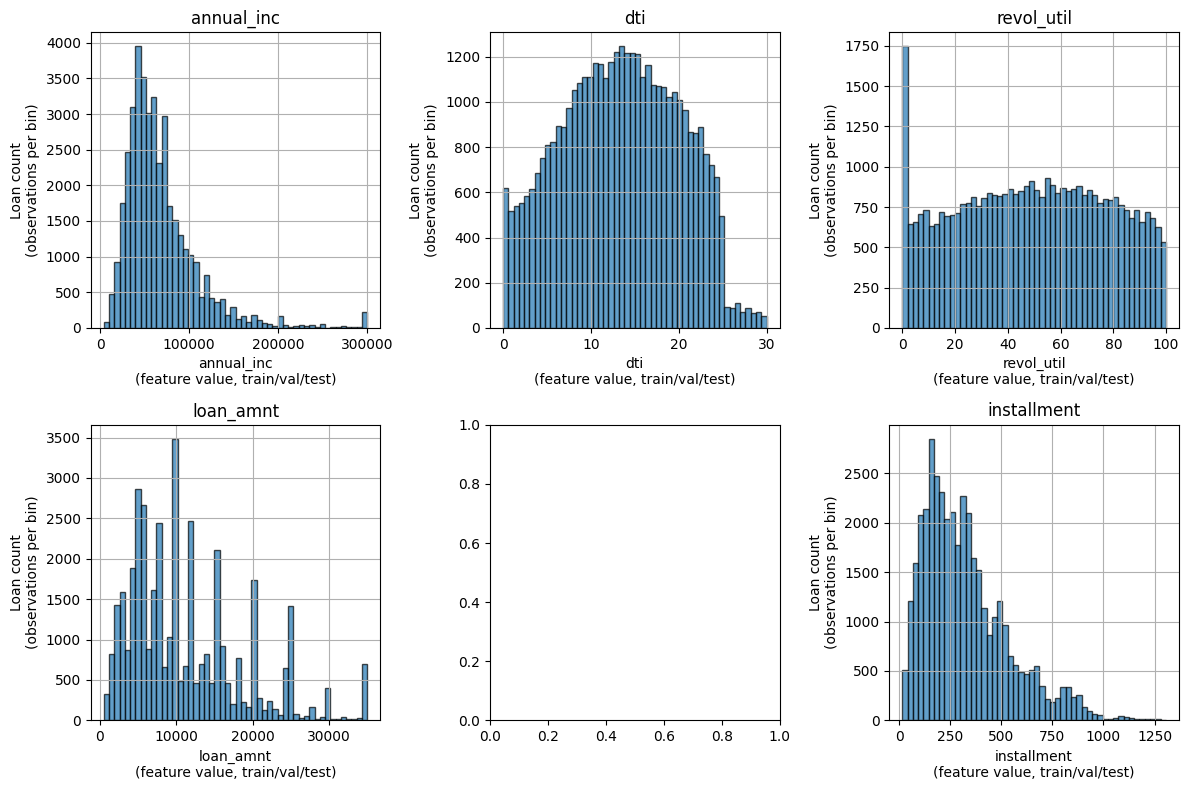

In [18]:
# Quick distribution plots (optional; comment out if no matplotlib)
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, col in zip(axes.flat, ["annual_inc", "dti", "revol_util", "loan_amnt", "fico_mid" if "fico_mid" in df.columns else "fico_low", "installment"]):
        if col in df.columns:
            df[col].dropna().hist(ax=ax, bins=50, edgecolor="black", alpha=0.7)
            ax.set_title(col)
            ax.set_xlabel(f"{col}\n(feature value, train/val/test)")
            ax.set_ylabel("Loan count\n(observations per bin)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plots skipped: {e}")

## 5. Build no-leakage PD features (common_features)

This notebook builds the **origination-only PD feature matrix** used for training and evaluation in this repo. Inputs are restricted to application-time LoanStats fields: post-origination payment and balance columns are dropped, and LendingClub outputs that encode the same underwriting signal as the label (`grade`, `sub_grade`, `int_rate`) are excluded from the model feature block.

The matrix combines compact engineered signals from `credit_risk/feature_engineering/common_features.py` (examples: DTI and utilization buckets, FICO bands, delinquency and inquiry flags, affordability ratios, purpose and tenure interactions, missingness flags, and log transforms) with **stable one-hot columns** for `purpose`, `home_ownership`, `verification_status`, `addr_state` (plus an unknown-state bucket), `application_type`, and `initial_list_status`, and with **additional raw origination numerics** when present (for example `term_months`, open and total account counts, public records and bankruptcies, mortgage accounts, and months since oldest installment and revolving accounts). The authoritative ordered column list is `get_feature_names_no_leakage_v2()`; the `_v2` suffix is only a code identifier for this expanded matrix, not a separate product version you must interpret on its own.

Categoricals are one-hot encoded from origination-time fields only (no post-origination risk grades), consistent with a strict no-leakage application PD design.

In [19]:
from credit_risk.feature_engineering.common_features import (
    build_features_from_dataframe_no_leakage_v2,
    get_feature_names_no_leakage_v2,
)

X_raw = df.copy()
X_feat = build_features_from_dataframe_no_leakage_v2(X_raw)
feature_names = get_feature_names_no_leakage_v2()
# int_rate is excluded from feature_names but saved in parquet for business demos only.
# Downstream training notebooks assert int_rate is absent from the model feature set.

print(f"{len(feature_names)} origination-only model features (expanded column list from common_features)")
print("First 20 features:", feature_names[:20])
print("Feature matrix shape:", X_feat.shape)

116 origination-only model features (expanded column list from common_features)
First 20 features: ['dti_ratio', 'dti_to_income', 'installment_to_income', 'payment_to_income_monthly', 'fico_mid', 'revol_util_pct', 'revol_util_bucket', 'loan_to_income', 'loan_to_income_bucket', 'emp_months', 'emp_length_years', 'delinq_flag', 'inq_6m', 'derog_composite', 'acc_util', 'revol_bal_log', 'revol_util_per_acc', 'fico_subprime', 'fico_range', 'fico_bucket']
Feature matrix shape: (39786, 116)


## 6. Fill NaN and attach target

Fill remaining NaNs in features with median (or 0 for flags) so that tree and quantum models receive numeric inputs only.

In [20]:
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)
    for c in X_feat.columns:
        if X_feat[c].isna().any():
            # Flags and one-hot columns should be 0 when missing
            if (
                "flag" in c
                or "high" in c
                or "subprime" in c
                or c.startswith("is_missing")
                or "__" in c  # one-hot columns
            ):
                X_feat[c] = X_feat[c].fillna(0.0)
            else:
                X_feat[c] = X_feat[c].fillna(X_feat[c].median())

    X_feat["default"] = df["default"].values
    X_feat["split"] = df["split"].values
    # Business-demo inputs only (not used as model features): loan_amnt, int_rate.
    # int_rate is Lending Club's risk-assigned rate (output of their model), not raw applicant
    # characteristics — so it stays excluded from our PD model training to avoid leakage.
    X_feat["loan_amnt"] = df["loan_amnt"].values
    if "int_rate_for_demo" in dir() and int_rate_for_demo is not None:
        X_feat["int_rate"] = int_rate_for_demo.values
    out_path = OUTPUT_DIR / "lendingclub_engineered.parquet"
    X_feat.to_parquet(out_path, index=False)
    _op = out_path.resolve()
    try:
        _op_disp = _op.relative_to(ROOT.resolve()).as_posix()
    except ValueError:
        _op_disp = str(_op)
    print(f"Saved engineered dataset to {_op_disp} ({len(X_feat):,} rows, {len(feature_names)} features + target + split).")


Saved engineered dataset to data\credit_risk_pd\LendingClub\processed\lendingclub_engineered.parquet (39,786 rows, 116 features + target + split).


## 7. Summary

- **Target:** default = 1 (Charged Off, Default, Late 31–120 days), non-default = 0 (Fully Paid only); ambiguous statuses dropped.
- **Leakage exclusion:** dropped funded_amnt, funded_amnt_inv, total_pymnt, total_pymnt_inv, recoveries, collection_recovery_fee, out_prncp, out_prncp_inv, last_pymnt_amnt, last_pymnt_d, grade, sub_grade, int_rate.
- **Time-based split (out-of-time):** train 2007–2009, val 2010, test 2011 by `issue_d`.
- **Origination-only model features** from `common_features` (engineered signals + one-hot categoricals + extra origination numerics as in section 5); NaNs filled; saved with `split` and `default` to `lendingclub_engineered.parquet`.
- Downstream notebooks should filter by `split` (train/val/test) and use `get_feature_names_no_leakage_v2()` for training/evaluation (and `parse_query_to_features(..., use_no_leakage=True, feature_version="v2")` for HF-style samples — here `feature_version` selects the expanded column list, matching `get_feature_names_no_leakage_v2()`).